In [2]:
import os
from tensorflow.keras.utils import get_file

file_path = '../data/Jena_Climate'
os.makedirs(file_path, exist_ok=True)

donwloaded_dile = get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_dir=file_path 
)

In [3]:
import numpy as np
import pandas as pd

DATA_PATH = '../data/jena_Climate/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv'

data = pd.read_csv(DATA_PATH)
data.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
df = data.drop(columns=['Date Time'])
df.isna().sum()


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

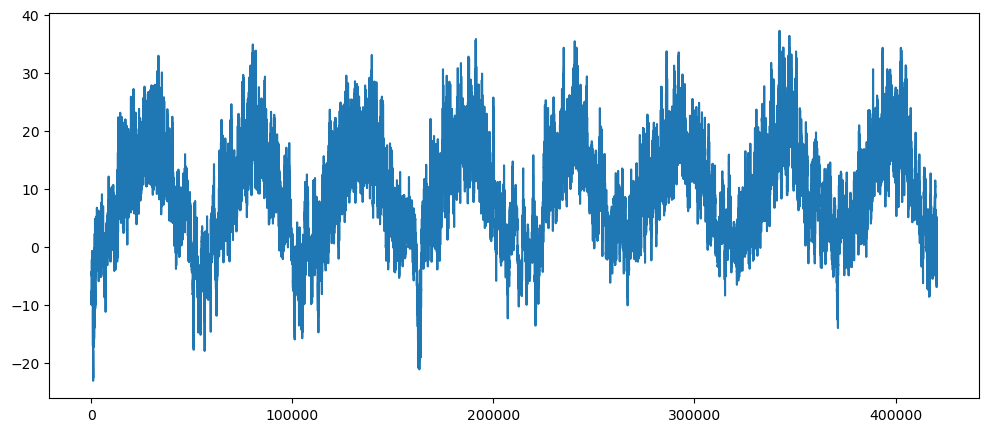

In [5]:
#Overall view of the temperature 
from matplotlib import pyplot as plt

temperature = df['T (degC)']
plt.figure(figsize=(12,5))
plt.plot(range(len(temperature)), temperature)
plt.show()

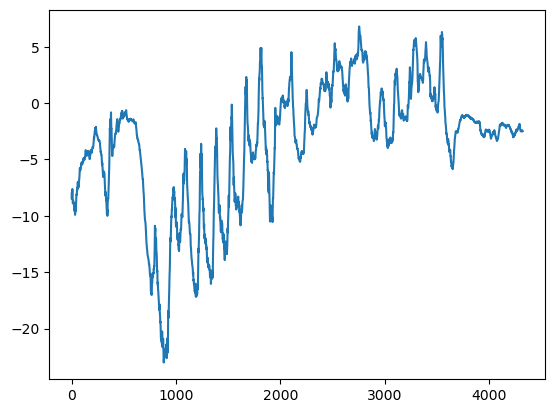

In [6]:
#Temperature over the firts 30 days
plt.plot(range(4320), temperature[:4320])
plt.show()

In [24]:
#Data preparation
from sklearn.preprocessing import StandardScaler
n_train_samples = int(0.5 * df.shape[0])
n_val_samples = int(0.25 * df.shape[0])
n_test_samples = df.shape[0] - n_train_samples - n_val_samples

data = df[:]
target = temperature[:]

scaler = StandardScaler()
scaler.fit(data[:n_train_samples].values)

data = scaler.transform(data.values)

In [25]:
from tensorflow import keras

sampling_rate = 6 
sequence_length = 120
delay = sampling_rate*(sequence_length+24-1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=n_train_samples
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay], 
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True, 
    batch_size=batch_size,
    start_index=n_train_samples,
    end_index=n_train_samples+n_val_samples
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay], 
    targets=target[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=n_train_samples+n_val_samples
)

In [26]:
for samples, targets in train_dataset:
    print('samples shape: ', samples.shape)
    print('targets shape: ', targets.shape)
    break

samples shape:  (256, 120, 14)
targets shape:  (256,)


In [27]:
#Testing a basic model with densely layer model
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint('jena_dense.keras', save_best_only=True)
]
model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model('jena_dense.keras')
print(f'Test MAE: {model.evaluate(test_dataset)[1]:.2f}')

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 12.2141 - mae: 2.7074 - val_loss: 11.2855 - val_mae: 2.6495
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 8.9308 - mae: 2.3506 - val_loss: 10.1347 - val_mae: 2.5180
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 8.1935 - mae: 2.2537 - val_loss: 10.9125 - val_mae: 2.6100
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 7.7698 - mae: 2.1962 - val_loss: 10.4021 - val_mae: 2.5416
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 7.4387 - mae: 2.1514 - val_loss: 13.4035 - val_mae: 2.9126
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 7.2289 - mae: 2.1210 - val_loss: 11.6908 - val_mae: 2.6997
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 7.0383 - mae: 2.0928 - val_loss: 10.8683 - val_mae: 2.5980
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 6.9234 - mae: 2.0757 - val_loss: 13.3695 - val_mae: 2.9018
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━

In [28]:
inputs = keras.Input(shape=(sequence_length, df.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks)
model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 32.7180 - mae: 4.3011 - val_loss: 18.4425 - val_mae: 3.3421
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 16.5873 - mae: 3.2341 - val_loss: 15.2132 - val_mae: 3.0718
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 15.3378 - mae: 3.1105 - val_loss: 18.0537 - val_mae: 3.4069
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 14.7034 - mae: 3.0459 - val_loss: 15.3189 - val_mae: 3.1088
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 14.1903 - mae: 2.9920 - val_loss: 15.2682 - val_mae: 3.1031
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 13.7977 - mae: 2.9473 - val_loss: 16.0219 - val_mae: 3.1289
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 13.4147 - mae: 2.9061 - val_loss: 14.8094 - val_mae: 3.0424
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 13.0462 - mae: 2.8635 - val_loss: 14.3943 - val_mae: 2.9892
Epoch 9/10
819/819 ━━━━━